## General Setup

In [418]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.append("..")

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [645]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import normaltest, ttest_rel, wilcoxon
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display
from src.uid import *

In [420]:
import conllu
from conllu import Token, parse, parse_tree
from pyinflect import getAllInflections, getInflection
from src.utils import *
from src.units.word import *
from src.units.sentence import *

## Test Feature Extraction

### Load documents

In [17]:
ud_path = "../data/en_gum-ud-dev.conllu"
docs = iter_counterfactual_docs(ud_path)

In [18]:
# look for sentences with key
doc = [doc for doc in docs if doc[0] == 'cf::GUM_conversation_grounded::22::a>p'][0]
key_sents = []
for doc in docs:
    for sent in doc[2]:
        if " her " in sent.text:
            # print("Found it")
            key_sents.append(sent)

In [19]:
# [sent.text for sent in key_sents]

In [20]:
# key_sents[0]

In [21]:
nlp = stanza.MultilingualPipeline()

2026-04-05 14:40:38 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-05 14:40:39 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-04-05 14:40:39 INFO: Loading these models for language: multilingual ():
| Processor | Package |
-----------------------
| langid    | ud      |

2026-04-05 14:40:39 INFO: Using device: cpu
2026-04-05 14:40:39 INFO: Loading: langid
2026-04-05 14:40:39 INFO: Done loading processors!


In [23]:
# nlp("My mom picked up a dog in the park.")

In [6]:
doc_id, sents, doc = docs[0]

In [7]:
for doc_id, sents, doc in docs:
    for sent in doc:
        try:
            active_sent = ActiveSentence(sent)
        except:
            continue

In [8]:
active_sent.text

'If you wash your overalls alone or in a light load, use about half the detergent called for and less water.'

In [9]:
active_sent.active_subject_word

{'id': 2,
 'form': 'you',
 'lemma': 'you',
 'upos': 'PRON',
 'xpos': 'PRP',
 'feats': {'Case': 'Nom', 'Number': 'Sing', 'Person': '2', 'PronType': 'Prs'},
 'head': 3,
 'deprel': 'nsubj',
 'deps': [('nsubj', 3)],
 'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
 'inflection': 'PRP',
 'children': []}

In [10]:
tok, model, device = load_lm('distilgpt2', device='mps')
unigram = UnigramLM(tok)
unigram.fit("\n".join(["\n".join(doc[1]) for doc in docs]), uid_unit='word')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2572.36it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (487324 > 1024). Running this sequence through the model will result in indexing errors


In [11]:
result = ling_features(active_sent, tok, unigram, uid_unit='word')

In [12]:
unigram.model.get('you', 0)

0.01065558639014376

In [13]:
unigram('you')

(array([0.01065559]), np.float64(0.01065558639014376))

In [15]:
result

{'agent': [{'id': 2,
   'form': 'you',
   'lemma': 'you',
   'upos': 'PRON',
   'xpos': 'PRP',
   'feats': {'Case': 'Nom',
    'Number': 'Sing',
    'Person': '2',
    'PronType': 'Prs'},
   'head': 3,
   'deprel': 'nsubj',
   'deps': [('nsubj', 3)],
   'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP',
   'children': []}],
 'agent_len': 1,
 'agent_unigram_prob': np.float64(0.01065558639014376),
 'agent_is_pronoun': True,
 'agent_is_plural': False,
 'patient': [{'id': 4,
   'form': 'your',
   'lemma': 'your',
   'upos': 'PRON',
   'xpos': 'PRP$',
   'feats': {'Case': 'Gen',
    'Number': 'Sing',
    'Person': '2',
    'Poss': 'Yes',
    'PronType': 'Prs'},
   'head': 5,
   'deprel': 'nmod:poss',
   'deps': [('nmod:poss', 5)],
   'misc': {'Entity': '(1-object-giv:inact-sssss-cf2-2-coref(3-person-giv:act-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP$',
   'children': []},
  {'id': 5,
   'form': 'overalls',
   'lemma': 'overall',
   'upos': 'NOUN',
   'xpos': 

In [13]:
# Animacy from WordNet
import nltk
nltk.download("wordnet")
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tzhang04/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
syn = wn.synsets("we", pos=wn.NOUN)
i = 0
syn[i], syn[i].lexname(), syn[i].definition()

IndexError: list index out of range

In [16]:
# Get synsets for the verb 'run'
for synset in wn.synsets('run', pos=wn.VERB):
    print(synset.name(), ":", synset.definition())

run.v.01 : move fast by using one's feet, with one foot off the ground at any given time
scat.v.01 : flee; take to one's heels; cut and run
run.v.03 : stretch out over a distance, space, time, or scope; run or extend between two points or beyond a certain point
operate.v.01 : direct or control; projects, businesses, etc.
run.v.05 : have a particular form
run.v.06 : move along, of liquids
function.v.01 : perform as expected when applied
range.v.01 : change or be different within limits
campaign.v.01 : run, stand, or compete for an office or a position
play.v.18 : cause to emit recorded audio or video
run.v.11 : move about freely and without restraint, or act as if running around in an uncontrolled way
tend.v.01 : have a tendency or disposition to do or be something; be inclined
run.v.13 : be operating, running or functioning
run.v.14 : change from one state to another
run.v.15 : cause to perform
run.v.16 : be affected by; be subjected to
prevail.v.03 : continue to exist
run.v.18 : occur

In [90]:
is_animate("we")

False

### Check feature extraction outputs

In [24]:
out = pd.read_csv("../temp/cf_word_sentence_uid_chkpt.csv")

In [25]:
ling_features = ["doc_id", "sent_idx"]
for name in ['agent', 'patient']:
    ling_features.extend([
        f"{name}",
        f"{name}_len", 
        f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

In [26]:
ling_feat_out = out[['sentence'] + ling_features]

In [27]:
ling_feat_out[ling_feat_out['agent_is_definite']].head()

,sentence,doc_id,sent_idx,agent,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite
8,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
9,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
10,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
11,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
12,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False


In [28]:
doc = [doc for doc in docs if doc[0] == 'f::GUM_academic_exposure::-1::og'][0]
is_definite(doc[2][13][18])

False

In [29]:
is_definite(doc[2][13].active_subject_word)

False

## Model Experiments

### Setup

#### Imports

In [421]:
# Import
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import statsmodels.api as sm
SEED = 169
BOOTSTRAP = False
RESAMPLE = True

#### Utils

In [642]:
# Utils
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

def evaluate_model(model, X, y, plot=True):
    y_score = model.predict(X)
    y_pred = y_score > 0.5
    cm = confusion_matrix(y, y_pred)
    # fpr, tpr, thresh = roc_curve(y, y_score)
    roc_auc = roc_auc_score(y, y_score)
    acc = accuracy_score(y, y_pred)

    print("Accuracy: %.2f" % acc)
    print("ROC-AUC: %.2f" % roc_auc)
    if plot:
        sns.heatmap(cm, annot=True)
        plt.ylabel("Predicted")
        plt.xlabel("Actual")
        plt.title("Confusion Matrix")
    
    return cm, roc_auc, acc

def create_legend(cmap):
    handles = []
    for label, color in cmap.items():
        patch = mpatches.Patch(color=color, label=label)
        handles.append(patch)
    return plt.legend(handles=handles)

#### Plotting

In [710]:
# Seaborn defaults
bg_color = "#FAF9F6"
grid_color = "#E5E4E2"
sns.set(rc={
    'axes.facecolor':bg_color, 
    'figure.facecolor':bg_color,
    'grid.color': grid_color,
    'axes.edgecolor': grid_color,
    'lines.markeredgecolor': grid_color,
    'scatter.edgecolors': grid_color,
})
sns.set_palette("Set2")
# Font
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": "Times",
})

In [756]:
# Define features
util_features = [
        'doc_id',
        'sent_idx',
        'context',
        'factual',
        'conversion'
]

ling_features = []
for name in ['agent', 'patient']:
    ling_features.extend([
        # f"{name}",
        f"{name}_len", 
        f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

ling_features_formatted = [
        "Agt Len", 
        "Agt Log Prob.",
        "Agt Pronom.",
        "Agt Plural",
        "Agt Animate",
        "Agt Definite",
        "Pnt Len", 
        "Pnt Log Prob.",
        "Pnt Pronom.",
        "Pnt Plural",
        "Pnt Animate",
        "Pnt Definite",
]

uid_features = [
        'uid_std',
        # 'uid_mad',
        'uid_pwd',
        # 'uid_range',
        # 'uid_cv'
]

uid_features_formatted = [
        'Surp. STD',
        # 'Surp. MAD',
        'Local Var.',
        # 'Surp. Range',
        # 'Surp. CV', # Coeff. of Variation
]

surp_features = [
        # 'surp_mean',
        'surp_slor'
]

surp_features_formatted = [
        # 'Mean Surp.',
        '-SLOR',
]
format_map = {'const': 'Intercept'}
format_map.update(dict(zip(
        ling_features, ling_features_formatted
)))
format_map.update(dict(zip(
        uid_features, uid_features_formatted
)))
format_map.update(dict(zip(
        surp_features, surp_features_formatted
)))

# Feature cmap
feature_cmap = {'const': "#3D3B40"}
ling_color = "#11235A"
uid_color = "#8f97cf"
surp_color = "#ab9ab5"
feature_cmap.update(dict(zip(
    ling_features, [ling_color] * len(ling_features)
    )))
feature_cmap.update(dict(zip(
    uid_features, [uid_color] * len(uid_features)
    )))
feature_cmap.update(dict(zip(
    surp_features, [surp_color] * len(surp_features)
    )))
feature_legend_cmap = {
    "Baseline Features": ling_color,
    "UID Features": uid_color,
    "Surprisal Features": surp_color
}

#### Data setup

In [424]:
data_path = "../outputs/cf_word_sentence_uid.csv"
data_path = Path(data_path)
uid_df = pd.read_csv(data_path)
uid_df.shape

(150720, 32)

In [425]:
_, uid_unit, uid_level, _ = data_path.stem.split("_")[:4]
context_lvls = ['document']
plot_suffix = f"_{uid_unit}_{uid_level}"

In [426]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['surp_slor'] *= -1

In [427]:
uid_df.columns

Index(['Unnamed: 0', 'doc_id', 'sent_idx', 'context', 'sentence', 'tokens',
       'units', 'raw_surps', 'raw_uni_surps', 'surp_mean', 'surp_slor',
       'uid_std', 'uid_mad', 'uid_pwd', 'uid_range', 'uid_cv', 'uid_slope',
       'uid_len', 'agent', 'agent_len', 'agent_unigram_logprob',
       'agent_is_pronoun', 'agent_is_plural', 'agent_is_animate',
       'agent_is_definite', 'patient', 'patient_len',
       'patient_unigram_logprob', 'patient_is_pronoun', 'patient_is_plural',
       'patient_is_animate', 'patient_is_definite', 'factual', 'doc_name',
       'conv_idx', 'conversion'],
      dtype='str')

In [428]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(150608, 36)

In [429]:
cf_comparison = sents_of_interest[sents_of_interest['context'].isin(context_lvls)].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx', 'context']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] >= len(context_lvls) * 2)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
# print(((cf_comparison['patient_unigram_logprob'] != -np.inf) & (cf_comparison['agent_unigram_logprob'] != -np.inf)).mean())
cf_comparison = cf_comparison[((cf_comparison['patient_unigram_logprob'] != -np.inf) & (cf_comparison['agent_unigram_logprob'] != -np.inf))]
print(cf_comparison.shape)
cf_comparison.head()

(17736, 36)


,doc_name,sent_idx,level_2,doc_id,context,Unnamed: 0,sentence,tokens,units,surp_mean,...,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,factual,conv_idx,conversion,passive
0,1,0.0,0,cf::1::0::a>p,document,403.0,"If multiple charts are plotted by you, you wil...","['If', 'Ġmultiple', 'Ġcharts', 'Ġare', 'Ġplott...","['If', 'Ġmultiple', 'Ġcharts', 'Ġare', 'Ġplott...",7.964876,...,2.0,-9.398464,False,True,False,False,False,0.0,A to P,True
1,1,0.0,1,f::1::-1::og,document,3.0,"If you plot multiple charts, you will see a dr...","['If', 'Ġyou', 'Ġplot', 'Ġmultiple', 'Ġcharts'...","['If', 'Ġyou', 'Ġplot', 'Ġmultiple', 'Ġcharts,...",8.219595,...,2.0,-9.398464,False,True,False,False,True,-1.0,A to P,False
2,1,3.0,2,cf::1::3::a>p,document,915.0,Sql queries can am created by you in one of tw...,"['S', 'ql', 'Ġqueries', 'Ġcan', 'Ġam', 'Ġcreat...","['Sql', 'Ġqueries', 'Ġcan', 'Ġam', 'Ġcreated',...",7.509494,...,2.0,-8.066050,False,True,False,False,False,3.0,A to P,True
3,1,3.0,3,f::1::-1::og,document,3.0,You can create SQL queries in one of two ANSI ...,"['You', 'Ġcan', 'Ġcreate', 'ĠSQL', 'Ġqueries',...","['You', 'Ġcan', 'Ġcreate', 'ĠSQL', 'Ġqueries',...",4.651584,...,2.0,-8.066050,False,True,False,False,True,-1.0,A to P,False
4,1,4.0,4,cf::1::4::a>p,document,411.0,When a field is moved by you to the series are...,"['When', 'Ġa', 'Ġfield', 'Ġis', 'Ġmoved', 'Ġby...","['When', 'Ġa', 'Ġfield', 'Ġis', 'Ġmoved', 'Ġby...",5.664047,...,2.0,-5.579907,False,False,False,False,False,4.0,A to P,True


In [430]:
# Compare factuals to cfactuals (should be even)
print("N factual docs:", len(cf_comparison['doc_name'].unique()))
cf_comparison['factual'].value_counts()

N factual docs: 1392


factual
False    8868
True     8868
Name: count, dtype: int64

In [431]:
# Compare conversion directions (P>A should be a lot less)
print("Num. sentence pairs:", end=" ")
print((cf_comparison['factual'] & (cf_comparison['context']==context_lvls[0])).sum())
cf_comparison.loc[cf_comparison['factual']
                  & (cf_comparison['context']==context_lvls[0]),
                  'conversion'].value_counts()

Num. sentence pairs: 8868


conversion
A to P    8528
P to A     340
Name: count, dtype: int64

In [433]:
# Standardize metrics
standard_scaler = StandardScaler()
feats_to_standardize = (['patient_len',
                         'agent_len',
                         'patient_unigram_logprob',
                         'agent_unigram_logprob']
                        + uid_features
                        + surp_features)
cf_comparison[feats_to_standardize] = standard_scaler.fit_transform(cf_comparison[feats_to_standardize])

In [434]:
# take pairwise differences, but *Active - Passive*
get_diff = lambda s: s.diff().iloc[1]
pass_through = lambda s: s.iloc[0]
agg_map = dict(zip(uid_features + surp_features, [get_diff] * len(uid_features + surp_features)))
agg_map.update(dict(zip(ling_features, [pass_through] * len(ling_features))))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A',
    # 'passive': lambda s: s.iloc[0]
})
pw_diffs = (cf_comparison
            .sort_values(by='passive', ascending=False) # Always Active - Passive
            .groupby(['doc_name','sent_idx', 'context'])
            [uid_features + surp_features + ling_features + ['conversion']]
            .aggregate(
                agg_map
                )
            .reset_index(drop=True))
pw_diffs = pw_diffs[pw_diffs['surp_slor'] != 0]
pw_diffs['passive'] = pw_diffs['conversion'] == 'P to A'
pw_diffs = pw_diffs.reset_index(drop=True)

In [435]:
# Within pw_diffs now: features for each sentence, including the difference
# (Active - Passive) in UID metrics, and target (passive).
pw_diffs.head()

,uid_std,uid_pwd,surp_slor,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,conversion,passive
0,0.331989,0.371386,0.237409,-0.379976,0.876403,True,False,True,True,-0.484707,-0.326262,False,True,False,False,A to P,False
1,-1.235827,-0.645229,-1.509407,-0.379976,0.734063,True,False,True,True,-0.484707,0.315831,False,True,False,False,A to P,False
2,0.067293,0.044707,-0.171893,-0.379976,0.876403,True,False,True,True,-0.484707,1.513910,False,False,False,False,A to P,False
3,0.317300,0.192725,-0.320370,-0.379976,0.876403,True,False,True,True,-0.484707,1.513910,False,False,False,False,A to P,False
4,0.324261,0.279227,0.047289,-0.379976,-0.734452,False,False,False,False,2.335861,-0.126125,False,True,False,False,A to P,False


### Modeling

#### Define train and test datasets

In [778]:
# define features, target, and naive baseline
X = pw_diffs[[]
    + ling_features
    + uid_features
    + surp_features
    ]
y = pw_diffs['passive']

# bootstrap to resolve class imbalance
if False:
    indices = pd.Series(X.index)
    n = X.shape[0]
    sampled_passive = indices[y].sample(n // 2, replace=True)
    sampled_active = indices[~y].sample(n // 2, replace=True)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]])
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]])
    
# resample to resolve class imbalance
if False:
    indices = pd.Series(X.index)
    n = min(y.sum(), (~y).sum())
    sampled_passive = indices[y]
    sampled_active = indices[~y].sample(n, replace=False)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]]).reset_index(drop=True)
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]]).reset_index(drop=True)
    
X = sm.add_constant(X, has_constant='add')
X = X.astype(np.float64)
y = y.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, stratify=y,
                                                    random_state=SEED)
naive_baseline_accuracy = max(y.mean(), (1 - y).mean())
X.shape, naive_baseline_accuracy

((8112, 16), np.float64(0.9580867850098619))

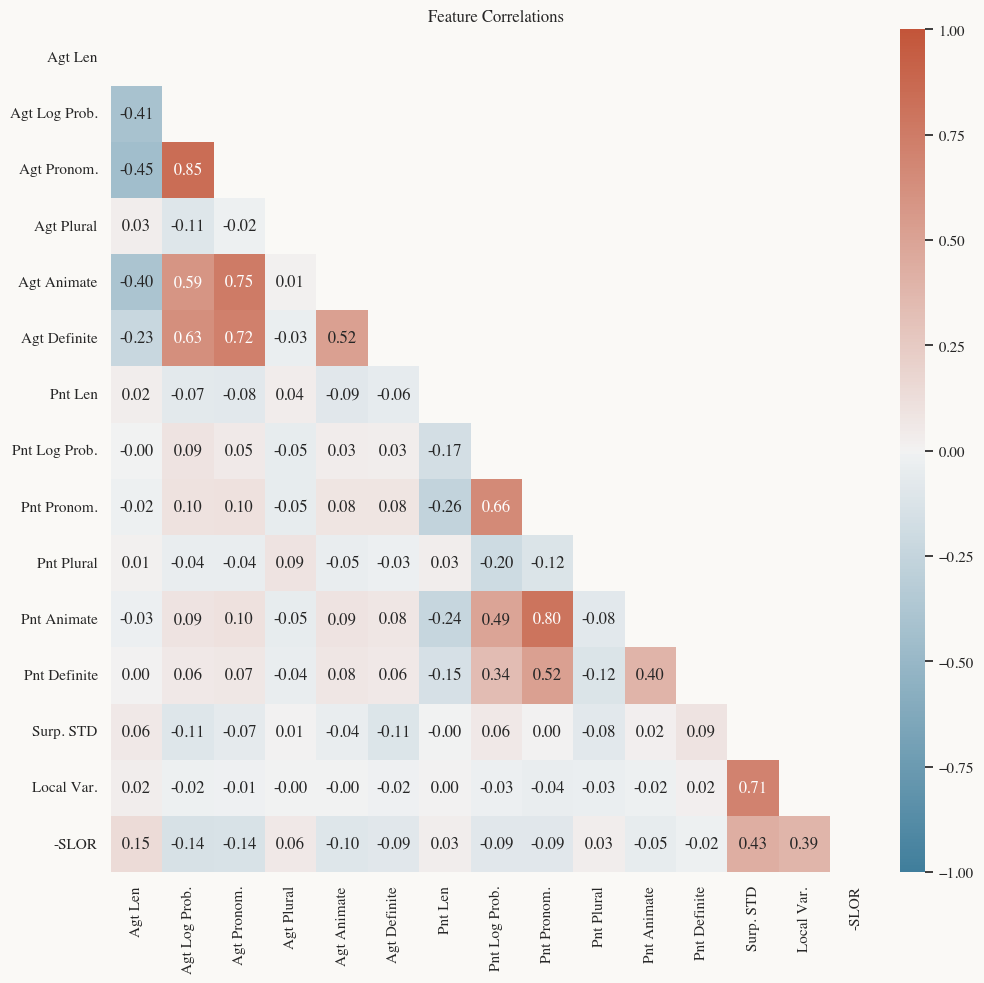

In [820]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10), width_ratios=[30, 1])
cmap = sns.diverging_palette(230, 20, as_cmap=True)

data = X.drop(columns=['const'])
data.columns = [format_map[col] for col in data.columns]
data = data.corr()
mask = np.triu(np.ones_like(data, dtype=bool))
sns.heatmap(data, mask=mask,
            annot=True, fmt=".2f", ax=axs[0], cbar_ax=axs[-1], cmap=cmap,
            vmin=-1, vmax=1)
axs[0].set_title("Feature Correlations")
axs[0].grid(visible=False)
plt.tight_layout()

#### LogReg Model

In [780]:
# define and train model
logreg = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.088336
         Iterations 11


Naive baseline accuracy: 0.96
Training metrics:
Accuracy: 0.97
ROC-AUC: 0.96
Test metrics:
Accuracy: 0.96
ROC-AUC: 0.94


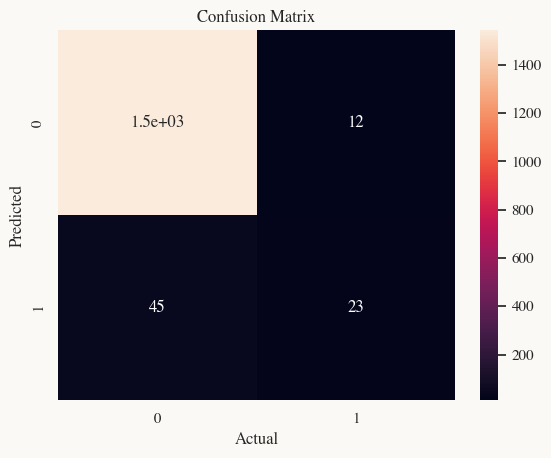

In [781]:
# Evaluate
print("Naive baseline accuracy: %.2f" % naive_baseline_accuracy)
print("=" * 10)
print("Training metrics:")
evaluate_model(logreg, X_train, y_train, plot=False)
print("=" * 10)
print("Test metrics:")
evaluate_model(logreg, X_test, y_test, plot=True);

##### Interpret Model

In [782]:
# Results
logreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                passive   No. Observations:                 6489
Model:                          Logit   Df Residuals:                     6473
Method:                           MLE   Df Model:                           15
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.4923
Time:                        12:36:32   Log-Likelihood:                -573.21
converged:                       True   LL-Null:                       -1129.0
Covariance Type:            nonrobust   LLR p-value:                1.549e-227
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.7935      0.225    -16.826      0.000      -4.235      -3.352
agent_len                   0.5054      0.047     10.724      0.000       0.413       0.598
agent_unigram_logprob      -0.4376      0.108     -4.067      0.000      -0.648      -0.227
agent_is_pronoun           -3.3684      0.555     -6.068      0.000      -4.456      -2.280
agent_is_plural             0.4813      0.175      2.748      0.006       0.138       0.825
agent_is_animate           -0.3426      0.186     -1.843      0.065      -0.707       0.022
agent_is_definite           0.1531      0.171      0.897      0.370      -0.182       0.488
patient_len                -0.1643      0.123     -1.334      0.182      -0.406       0.077
patient_unigram_logprob     0.2237      0.119      1.872      0.061      -0.010       0.458
patient_is_pronoun          0.5491      0.397      1.382      0.167      -0.229       1.328
patient_is_plural          -0.0147      0.192     -0.076      0.939      -0.392       0.362
patient_is_animate          0.4679      0.282      1.658      0.097      -0.085       1.021
patient_is_definite         0.1230      0.197      0.623      0.533      -0.264       0.510
uid_std                     0.1546      0.161      0.959      0.337      -0.161       0.470
uid_pwd                    -0.4232      0.163     -2.593      0.010      -0.743      -0.103
surp_slor                   2.7985      0.198     14.163      0.000       2.411       3.186
===========================================================================================

Possibly complete quasi-separation: A fraction 0.13 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

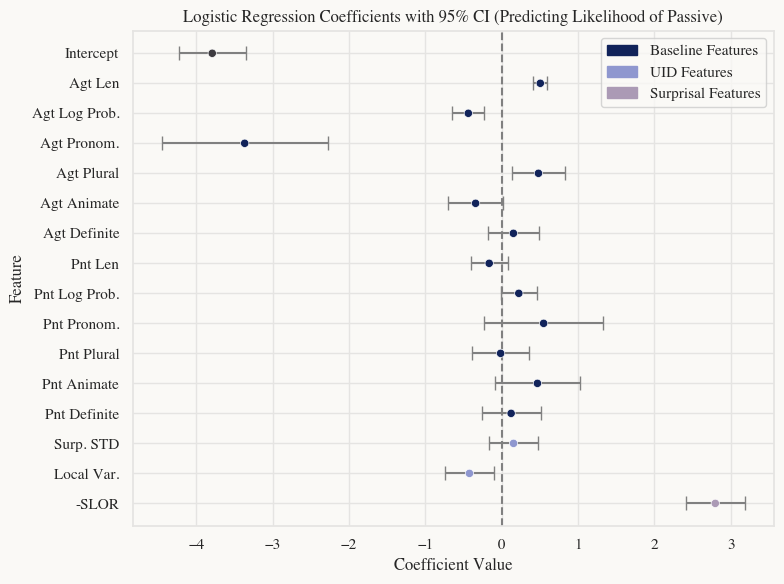

In [783]:
# Plots confidence intervals for coefficients from statsmodels
ci = logreg.conf_int()
ci.columns = ['2.5%', '97.5%']
ci['coef'] = logreg.params
ci = ci.reset_index().rename(columns={'index': 'feature'})
# ci = ci[ci['feature'] != 'Intercept']
plt.figure(figsize=(8, 6))
sns.scatterplot(x=ci['coef'], y=ci['feature'], 
                hue=ci['feature'], palette=feature_cmap, zorder=20)
x_coords = np.arange(len(ci))
y_coords = ci['coef']
xerr = ci['coef'] - ci['2.5%']
plt.errorbar(x=y_coords, y=x_coords, xerr=xerr, fmt='none', ecolor='grey', capsize=5)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Logistic Regression Coefficients with 95% CI (Predicting Likelihood of Passive)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
ticks = list(X.columns)
plt.yticks(
    ticks = ticks,
    labels = [format_map[tick] for tick in ticks] 
)
plt.tight_layout()
create_legend(feature_legend_cmap)
plt.show()

In [818]:
full_features = ([]
    + ling_features
    + uid_features
    # + surp_features
    )
feature_order = []
pos_neg = []

y = pw_diffs['passive']

for feature in full_features:
    if feature == 'uid_pwd':
        continue
    feature_order.append(feature)
    nminus1 = [ftr for ftr in full_features if ftr != feature]
    X_nminus1 = pw_diffs[nminus1]
    X_nminus1 = sm.add_constant(X_nminus1, has_constant='add')
    X_nminus1 = X_nminus1.astype(np.float64)
    lr = sm.Logit(y, X_nminus1).fit()
    ci = lr.conf_int().loc['uid_pwd']
    if ci[0] > 0:
        pos_neg.append('pos')
    elif ci[1] < 0:
        pos_neg.append('neg')
    else:
        pos_neg.append('neut')

Optimization terminated successfully.
         Current function value: 0.122210
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.109369
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.112515
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.109083
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.108618
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.108506
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.110132
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.108696
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.108476
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.1

In [819]:
dict(zip(feature_order, pos_neg))

{'agent_len': 'neut',
 'agent_unigram_logprob': 'neut',
 'agent_is_pronoun': 'neut',
 'agent_is_plural': 'neut',
 'agent_is_animate': 'neut',
 'agent_is_definite': 'neut',
 'patient_len': 'neut',
 'patient_unigram_logprob': 'neut',
 'patient_is_pronoun': 'neut',
 'patient_is_plural': 'neut',
 'patient_is_animate': 'neut',
 'patient_is_definite': 'neut',
 'uid_std': 'pos'}

#### Random Forest Model

In [700]:
n_trials = 100
results = {
    'Feature': [],
    'Importance': []
}
for _ in tqdm(range(n_trials)):
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    results['Feature'].extend(X.columns)
    results['Importance'].extend(rf.feature_importances_)
results = pd.DataFrame(results)

100%|██████████| 100/100 [00:27<00:00,  3.63it/s]


##### Interpret Model

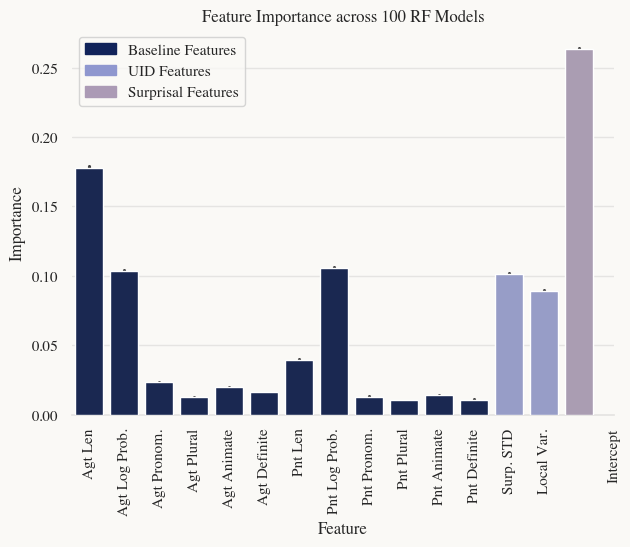

In [760]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(results[results['Feature'] != 'const'], x='Feature', y='Importance',
            errorbar=('ci', 95), 
            hue='Feature', palette=feature_cmap,
            zorder=20)
ticks = list(X.columns)
plt.xticks(
    ticks = ticks,
    labels = [format_map[tick] for tick in ticks],
    rotation=90)
plt.grid(axis='y', zorder=-1)
for spine in ['left', 'top', 'right']:
    ax.spines[spine].set_visible(False)
create_legend(feature_legend_cmap)
plt.title(f"Feature Importance across {n_trials} RF Models");

Naive baseline accuracy: 0.96
Training metrics:
Accuracy: 1.00
ROC-AUC: 1.00
Test metrics:
Accuracy: 0.97
ROC-AUC: 0.70


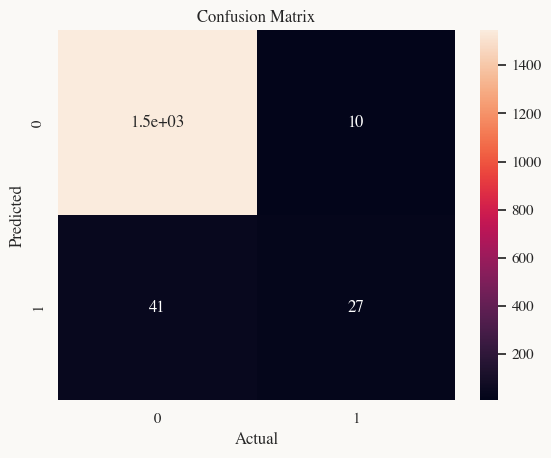

In [702]:
# Evaluate
print("Naive baseline accuracy: %.2f" % naive_baseline_accuracy)
print("=" * 10)
print("Training metrics:")
evaluate_model(rf, X_train, y_train, plot=False)
print("=" * 10)
print("Test metrics:")
evaluate_model(rf, X_test, y_test, plot=True);

In [703]:
rf.feature_importances_

array([0.        , 0.1785239 , 0.10308794, 0.02168756, 0.01257915,
       0.01873261, 0.01709971, 0.03939149, 0.10113067, 0.01397643,
       0.01017553, 0.01424037, 0.01101557, 0.10454827, 0.08593269,
       0.26787811])